# Bidirectional LSTM with GloVe Embeddings
**Dataset:** IMDB 50K Movie Reviews (HuggingFace)  
**Embeddings:** GloVe 100-dimensional pre-trained vectors  
**Goal:** Capture sequential and contextual patterns in reviews using a deep learning approach.

import re
import os
import json
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for CI
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED  = 42
MAX_VOCAB    = 30_000
MAX_LEN      = 256
EMBED_DIM    = 100
BATCH_SIZE   = 128
EPOCHS       = 10

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'TensorFlow version: {tf.__version__}')

In [1]:
import re
import os
import json
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED  = 42
MAX_VOCAB    = 30_000   # vocabulary size cap
MAX_LEN      = 256      # max sequence length (tokens)
EMBED_DIM    = 100      # GloVe dimension
BATCH_SIZE   = 128
EPOCHS       = 10

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load Dataset

In [2]:
dataset = load_dataset('stanfordnlp/imdb')

train_texts = dataset['train']['text']
train_labels = np.array(dataset['train']['label'])
test_texts  = dataset['test']['text']
test_labels = np.array(dataset['test']['label'])

print(f'Train: {len(train_texts):,} | Test: {len(test_texts):,}')

Train: 25,000 | Test: 25,000


## 3. Text Preprocessing

In [3]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)      # remove HTML
    text = re.sub(r'[^a-z\s]', ' ', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_clean = [preprocess(t) for t in train_texts]
test_clean  = [preprocess(t) for t in test_texts]
print('Preprocessing done.')

Preprocessing done.


## 4. Tokenization & Padding

In [4]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_clean)

word_index = tokenizer.word_index
print(f'Unique tokens in corpus: {len(word_index):,}')
print(f'Vocabulary capped at   : {MAX_VOCAB:,}')

# Convert text to integer sequences
train_seq = tokenizer.texts_to_sequences(train_clean)
test_seq  = tokenizer.texts_to_sequences(test_clean)

# Pad/truncate to fixed length
X_train = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

# Sequence length distribution
seq_lens = [len(s) for s in train_seq]
print(f'\nSequence length, Mean: {np.mean(seq_lens):.0f} | Max: {max(seq_lens)} | 95th pct: {np.percentile(seq_lens, 95):.0f}')

Unique tokens in corpus: 73,268
Vocabulary capped at   : 30,000



X_train shape: (25000, 256)
X_test  shape: (25000, 256)

Sequence length, Mean: 237 | Max: 2494 | 95th pct: 608


## 5. Load GloVe Embeddings

In [5]:
GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'

# Download GloVe if not already present
if not os.path.exists(GLOVE_PATH):
    print('Downloading GloVe 6B 100d embeddings (~822 MB)...')
    r = requests.get(GLOVE_URL, stream=True)
    with open('glove.6B.zip', 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Extracting...')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract('glove.6B.100d.txt')
    os.remove('glove.6B.zip')
    print('GloVe ready.')
else:
    print('GloVe file already exists, skipping download.')

# Parse GloVe vectors into a dict
glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f'Loaded {len(glove_embeddings):,} GloVe vectors.')

Extracting...


GloVe ready.


Loaded 400,000 GloVe vectors.


In [6]:
# Build embedding matrix aligned with our tokenizer vocabulary
embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Embedding coverage: {hits:,} hits / {misses:,} misses ({coverage:.1f}%)')

Embedding coverage: 29,384 hits / 615 misses (97.9%)


## 6. Build Bidirectional LSTM Model

In [7]:
def build_bilstm(vocab_size, embed_dim, embed_matrix, max_len):
    model = Sequential([
        # Frozen GloVe embedding layer
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embed_matrix],
            input_length=max_len,
            trainable=False,
            name='glove_embedding'
        ),
        # First BiLSTM layer, returns sequences for stacking
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        # Second BiLSTM layer
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_bilstm(MAX_VOCAB, EMBED_DIM, embedding_matrix, MAX_LEN)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

## 7. Train Model

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

t0 = time.time()
history = model.fit(
    X_train, train_labels,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - t0
print(f'\nTraining time: {train_time:.1f}s')

Epoch 1/10


  1/176 ━━━━━━━━━━━━━━━━━━━━ 17:46 6s/step - accuracy: 0.4531 - loss: 0.7130

  2/176 ━━━━━━━━━━━━━━━━━━━━ 2:12 763ms/step - accuracy: 0.4648 - loss: 0.7016

  3/176 ━━━━━━━━━━━━━━━━━━━━ 2:10 756ms/step - accuracy: 0.4870 - loss: 0.7004

  4/176 ━━━━━━━━━━━━━━━━━━━━ 2:03 718ms/step - accuracy: 0.5234 - loss: 0.6918

...

175/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8233 - loss: 0.4023

176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8235 - loss: 0.4022

176/176 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.8235 - loss: 0.4022 - val_accuracy: 0.8504 - val_loss: 0.3630 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 10.



Training time: 2645.7s


## 8. Training Curves

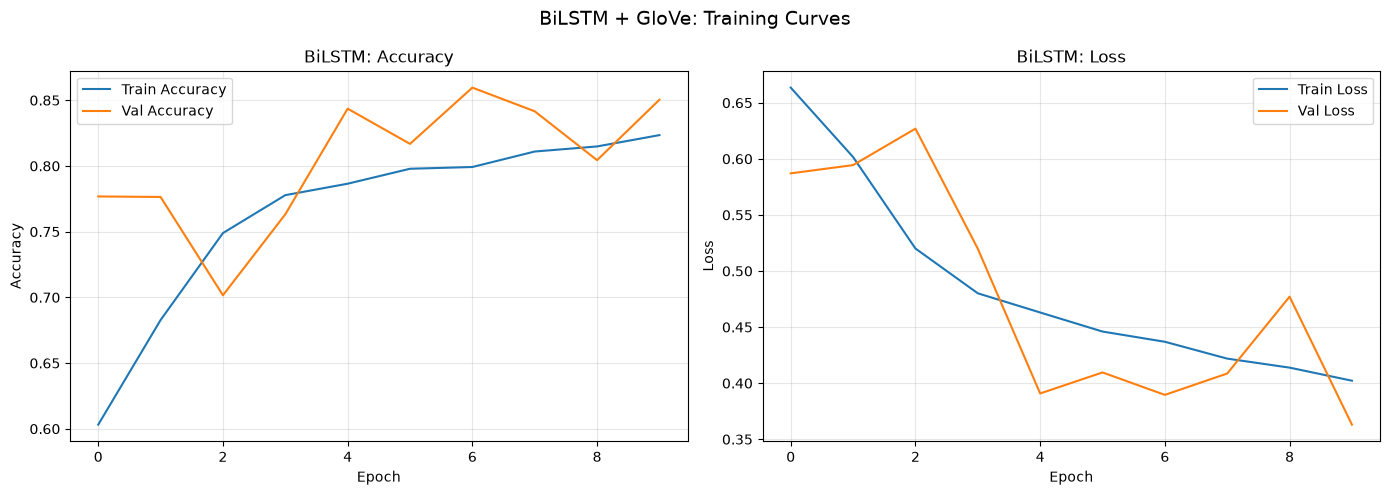

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('BiLSTM: Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('BiLSTM: Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM + GloVe: Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('results/lstm_training_curves.png', dpi=150)
plt.show()

## 9. Evaluation

In [10]:
t0 = time.time()
prob_preds = model.predict(X_test, batch_size=256, verbose=0).squeeze()
latency_ms = (time.time() - t0) / len(test_labels) * 1000

preds = (prob_preds >= 0.5).astype(int)

acc = accuracy_score(test_labels, preds)
f1  = f1_score(test_labels, preds, average='binary')

print(f'Accuracy         : {acc:.4f}')
print(f'F1 Score         : {f1:.4f}')
print(f'Latency/sample   : {latency_ms:.4f} ms')
print()
print(classification_report(test_labels, preds, target_names=['Negative', 'Positive']))

Accuracy         : 0.8378
F1 Score         : 0.8411
Latency/sample   : 2.9865 ms

              precision    recall  f1-score   support

    Negative       0.85      0.82      0.83     12500
    Positive       0.82      0.86      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



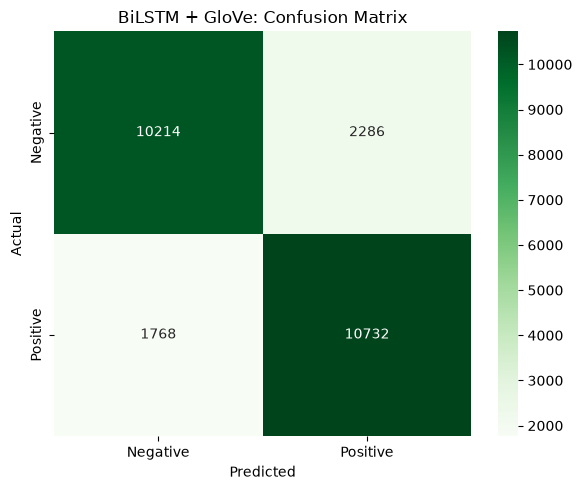

In [11]:
# Confusion matrix
cm = confusion_matrix(test_labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('BiLSTM + GloVe: Confusion Matrix')
plt.tight_layout()
plt.savefig('results/lstm_confusion_matrix.png', dpi=150)
plt.show()

## 10. Save Metrics

In [12]:
metrics = {
    'model'       : 'Bidirectional LSTM + GloVe 100d',
    'accuracy'    : round(acc, 4),
    'f1_score'    : round(f1, 4),
    'latency_ms'  : round(latency_ms, 4),
    'train_time_s': round(train_time, 2),
    'epochs_ran'  : len(history.history['loss'])
}

with open('results/lstm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Metrics saved to results/lstm_metrics.json')
print(json.dumps(metrics, indent=2))

Metrics saved to results/lstm_metrics.json
{
  "model": "Bidirectional LSTM + GloVe 100d",
  "accuracy": 0.8378,
  "f1_score": 0.8411,
  "latency_ms": 2.9865,
  "train_time_s": 2645.69,
  "epochs_ran": 10
}
